# Forecast Dataset EDA Template (Truthful, Reproducible)

This notebook is a structured, cell-by-cell workflow for inspecting **forecasting** datasets before training. It does not fabricate outputs; all results come from the loaded data.

## How to use
1. Set `DATASET_KEY` (for OptiWMS datasets) or `CSV_PATH`.
2. Run cells from top to bottom.
3. Review the plots and checks to decide if the dataset is suitable for multi-horizon forecasting.

## What this checks
- Time coverage and missing months
- Series length distribution
- Target distribution and seasonality
- Missingness in optional exogenous features
- Horizon readiness for lags/rolling windows
- Basic correlation scan for numeric features
- Suitability checklist summary


In [16]:
# 1) Import Libraries and Configure Plotting
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8")
sns.set_palette("husl")

print("Libraries imported successfully")


Libraries imported successfully


In [17]:
# 2) Load Dataset and Inspect Schema
# Use DATASET_KEY for OptiWMS datasets, or set CSV_PATH for a custom file.

# Available dataset keys (uncomment one):
# DATASET_KEY = "A"
# DATASET_KEY = "B"
# DATASET_KEY = "C"
# DATASET_KEY = "P"
# DATASET_KEY = "PV2"
# DATASET_KEY = "W"
# DATASET_KEY = "WV2"
# DATASET_KEY = "RMV2"
DATASET_KEY = "B"  # active selection
CSV_PATH = ""      # optional direct path override

TIME_COL = "month"
TARGET_COL = "demand_units"
SERIES_COL = "fg_code"
CATEGORY_COL = "fg_category"

EXOG_COLS = [
    "on_hand_inventory",
    "stockout_days",
    "promotion_flag",
    "price_or_discount",
    "lead_time_days",
    "supplier_otif",
    "inbound_po_qty",
    "open_sales_orders",
    "returns_qty",
    "holiday_flag",
]

try:
    from common import load_dataset
except Exception:
    import sys
    from pathlib import Path

    here = Path.cwd()
    scripts_dir = here.parent / "scripts"
    if scripts_dir.exists() and str(scripts_dir) not in sys.path:
        sys.path.insert(0, str(scripts_dir))
    from common import load_dataset

if CSV_PATH:
    df = pd.read_csv(CSV_PATH)
else:
    df = load_dataset(DATASET_KEY)

print("Dataset Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
missing_info = df.isnull().sum()
print(missing_info[missing_info > 0])

print("\nDataset loaded successfully")


In [18]:
# 3) Initial Data Preview and Summary Stats
print("\nHead:")
print(df.head())

print("\nInfo:")
df.info()

id_like = {"id", "order_id", "Unnamed: 0"}
num_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in id_like]
print("\nDescribe (numeric, non-ID):")
if num_cols:
    print(df[num_cols].describe())
else:
    print("No numeric columns found.")


In [19]:
# 4) Check Duplicates and Missing Values
duplicate_count = df.duplicated().sum()
print(f"Total duplicate records found: {duplicate_count}")

missing_info = df.isnull().sum().sort_values(ascending=False)
print("\nMissing values per column:")
print(missing_info[missing_info > 0])


In [20]:
# 5) Time Coverage and Continuity Checks
if TIME_COL in df.columns:
    df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")

if TIME_COL in df.columns and SERIES_COL in df.columns:
    min_date = df[TIME_COL].min()
    max_date = df[TIME_COL].max()
    months_total = df[TIME_COL].dt.to_period("M").nunique()
    print(f"Time range: {min_date} to {max_date}")
    print(f"Distinct months: {months_total}")

    series_months = (
        df.dropna(subset=[TIME_COL])
        .groupby(SERIES_COL)[TIME_COL]
        .apply(lambda s: s.dt.to_period("M").nunique())
        .rename("months")
        .reset_index()
    )
    print("\nSeries month coverage (summary):")
    print(series_months["months"].describe())
else:
    print("Missing TIME_COL or SERIES_COL; cannot compute time coverage.")


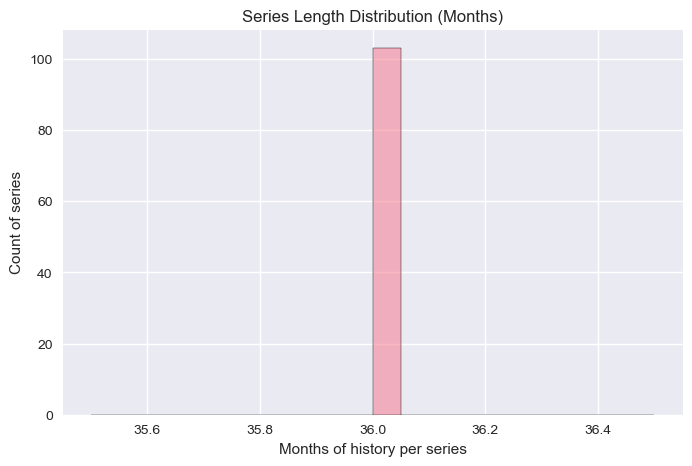

In [21]:
# 6) Series Length Distribution
if TIME_COL in df.columns and SERIES_COL in df.columns:
    series_months = (
        df.dropna(subset=[TIME_COL])
        .groupby(SERIES_COL)[TIME_COL]
        .apply(lambda s: s.dt.to_period("M").nunique())
        .rename("months")
        .reset_index()
    )
    plt.figure(figsize=(8, 5))
    sns.histplot(series_months["months"], bins=20, kde=True)
    plt.title("Series Length Distribution (Months)")
    plt.xlabel("Months of history per series")
    plt.ylabel("Count of series")
    plt.show()
else:
    print("Missing TIME_COL or SERIES_COL; cannot plot series length.")


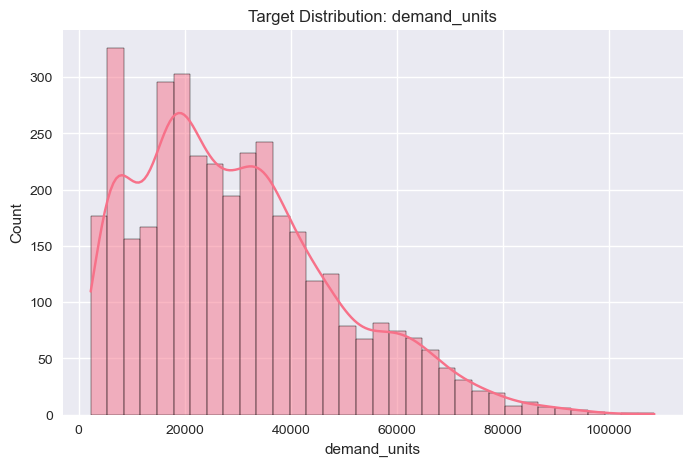

In [22]:
# 7) Target Distribution Analysis
if TARGET_COL in df.columns:
    target_vals = df[TARGET_COL].dropna()
    print("Target summary:")
    print(target_vals.describe())
    plt.figure(figsize=(8, 5))
    sns.histplot(target_vals, kde=True)
    plt.title(f"Target Distribution: {TARGET_COL}")
    plt.xlabel(TARGET_COL)
    plt.ylabel("Count")
    plt.show()
else:
    print("Target column not found.")


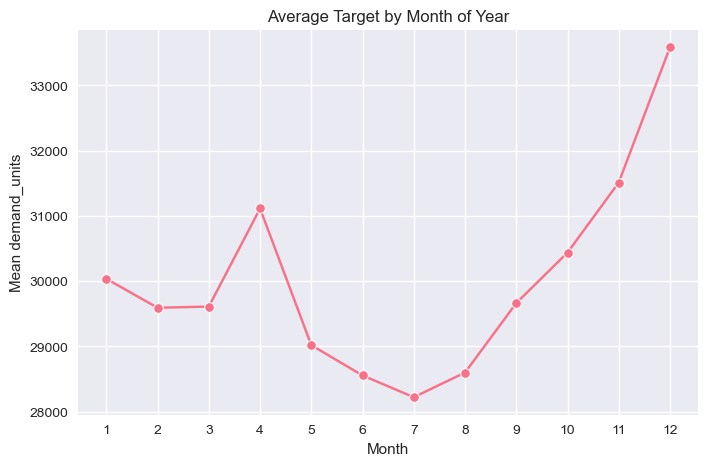

In [23]:
# 8) Seasonality Check (Month-of-Year)
if TIME_COL in df.columns and TARGET_COL in df.columns:
    monthly = df.dropna(subset=[TIME_COL]).copy()
    monthly["month_num"] = monthly[TIME_COL].dt.month
    seasonality = monthly.groupby("month_num")[TARGET_COL].mean().reset_index()
    plt.figure(figsize=(8, 5))
    sns.lineplot(data=seasonality, x="month_num", y=TARGET_COL, marker="o")
    plt.title("Average Target by Month of Year")
    plt.xlabel("Month")
    plt.ylabel(f"Mean {TARGET_COL}")
    plt.xticks(range(1, 13))
    plt.show()
else:
    print("Missing TIME_COL or TARGET_COL; cannot compute seasonality.")


In [24]:
# 9) Missing Month Gaps per Series
if TIME_COL in df.columns and SERIES_COL in df.columns:
    tmp = df.dropna(subset=[TIME_COL]).copy()
    tmp["period"] = tmp[TIME_COL].dt.to_period("M")
    gaps = []
    for sid, g in tmp.groupby(SERIES_COL):
        periods = g["period"].sort_values().unique()
        if len(periods) < 2:
            gaps.append({"series_id": sid, "missing_months": None})
            continue
        all_periods = pd.period_range(periods.min(), periods.max(), freq="M")
        missing = len(all_periods.difference(periods))
        gaps.append({"series_id": sid, "missing_months": missing})
    gaps_df = pd.DataFrame(gaps)
    print("Missing month gaps per series (summary):")
    print(gaps_df["missing_months"].dropna().describe())
else:
    print("Missing TIME_COL or SERIES_COL; cannot compute gaps.")


In [25]:
# 10) Exogenous Feature Coverage
present_exog = [c for c in EXOG_COLS if c in df.columns]
if present_exog:
    exog_missing = df[present_exog].isnull().mean().sort_values(ascending=False)
    print("Missing rate for exogenous features:")
    print(exog_missing)
else:
    print("No exogenous columns found in this dataset.")


In [26]:
# 11) Horizon Readiness (lags/rolling windows)
if TIME_COL in df.columns and SERIES_COL in df.columns:
    tmp = df.dropna(subset=[TIME_COL]).copy()
    tmp["period"] = tmp[TIME_COL].dt.to_period("M")
    series_months = (
        tmp.groupby(SERIES_COL)["period"]
        .nunique()
        .rename("months")
        .reset_index()
    )
    for req in [6, 12, 18, 24, 36]:
        ready = (series_months["months"] >= req).mean()
        print(f"Series with >= {req} months: {ready:.1%}")
else:
    print("Missing TIME_COL or SERIES_COL; cannot compute readiness.")


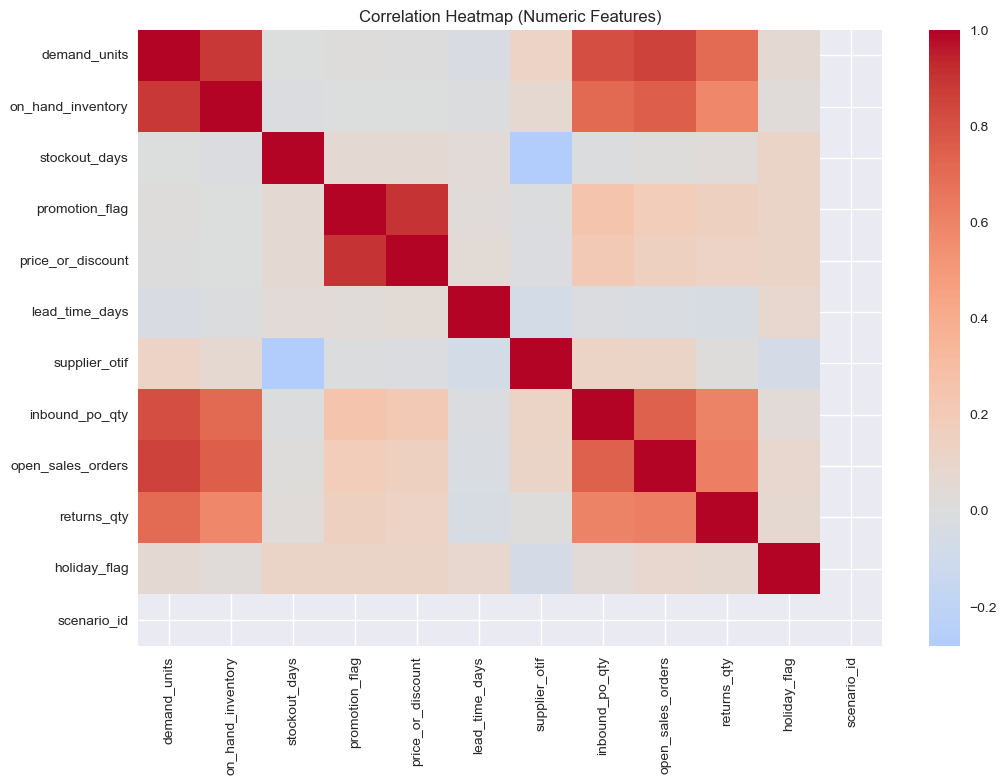

In [27]:
# 12) Correlation Heatmap (Numeric Features)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ["id", "order_id", "Unnamed: 0"]]

if len(num_cols) >= 2:
    corr = df[num_cols].corr()
    plt.figure(figsize=(12, 8))
    sns.heatmap(corr, cmap="coolwarm", center=0)
    plt.title("Correlation Heatmap (Numeric Features)")
    plt.show()

    if TARGET_COL in corr.columns:
        top_corr = corr[TARGET_COL].sort_values(ascending=False)
        print("Top correlations with target:")
        print(top_corr.head(10))
else:
    print("Not enough numeric columns for correlation heatmap.")


In [28]:
# 13) Suitability Checklist
checks = {}

if TIME_COL in df.columns:
    months_total = df[TIME_COL].dt.to_period("M").nunique()
    checks["months_total>=24"] = months_total >= 24
else:
    checks["months_total>=24"] = False

if TIME_COL in df.columns and SERIES_COL in df.columns:
    series_months = (
        df.dropna(subset=[TIME_COL])
        .groupby(SERIES_COL)[TIME_COL]
        .apply(lambda s: s.dt.to_period("M").nunique())
    )
    checks["p50_series_months>=18"] = series_months.median() >= 18
    checks["p90_series_months>=12"] = series_months.quantile(0.9) >= 12
else:
    checks["p50_series_months>=18"] = False
    checks["p90_series_months>=12"] = False

if TARGET_COL in df.columns:
    checks["target_non_negative"] = (df[TARGET_COL].dropna() >= 0).all()
else:
    checks["target_non_negative"] = False

print("Suitability checklist:")
for k, v in checks.items():
    print(f"- {k}: {v}")


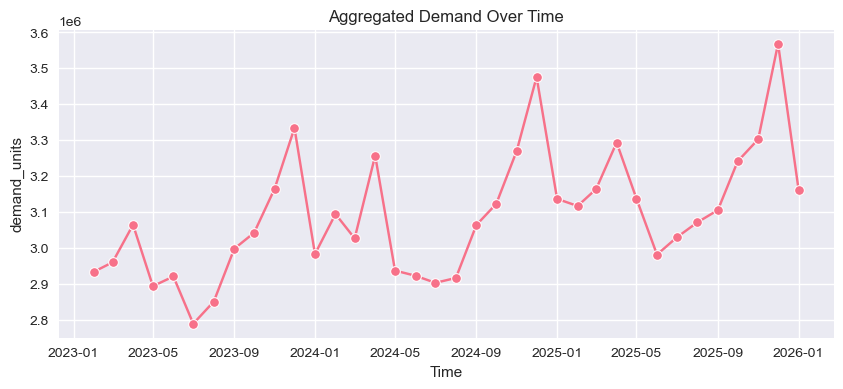

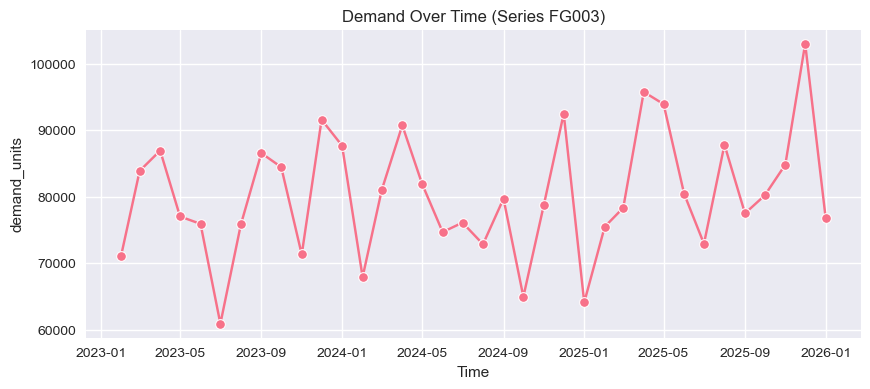

In [29]:
# 14) Time Series Plot (Aggregated + Sample SKU)
if TIME_COL in df.columns and TARGET_COL in df.columns:
    ts = df.dropna(subset=[TIME_COL]).copy()
    ts[TIME_COL] = pd.to_datetime(ts[TIME_COL], errors="coerce")
    agg = ts.groupby(ts[TIME_COL].dt.to_period("M"))[TARGET_COL].sum().reset_index()
    agg[TIME_COL] = agg[TIME_COL].dt.to_timestamp()

    plt.figure(figsize=(10, 4))
    sns.lineplot(data=agg, x=TIME_COL, y=TARGET_COL, marker="o")
    plt.title("Aggregated Demand Over Time")
    plt.xlabel("Time")
    plt.ylabel(TARGET_COL)
    plt.show()

    if SERIES_COL in df.columns:
        top_series = (
            df.groupby(SERIES_COL)[TARGET_COL]
            .sum()
            .sort_values(ascending=False)
            .head(1)
            .index.tolist()
        )
        if top_series:
            sid = top_series[0]
            series_df = ts[ts[SERIES_COL] == sid].sort_values(TIME_COL)
            plt.figure(figsize=(10, 4))
            sns.lineplot(data=series_df, x=TIME_COL, y=TARGET_COL, marker="o")
            plt.title(f"Demand Over Time (Series {sid})")
            plt.xlabel("Time")
            plt.ylabel(TARGET_COL)
            plt.show()
else:
    print("Missing TIME_COL or TARGET_COL; cannot plot time series.")


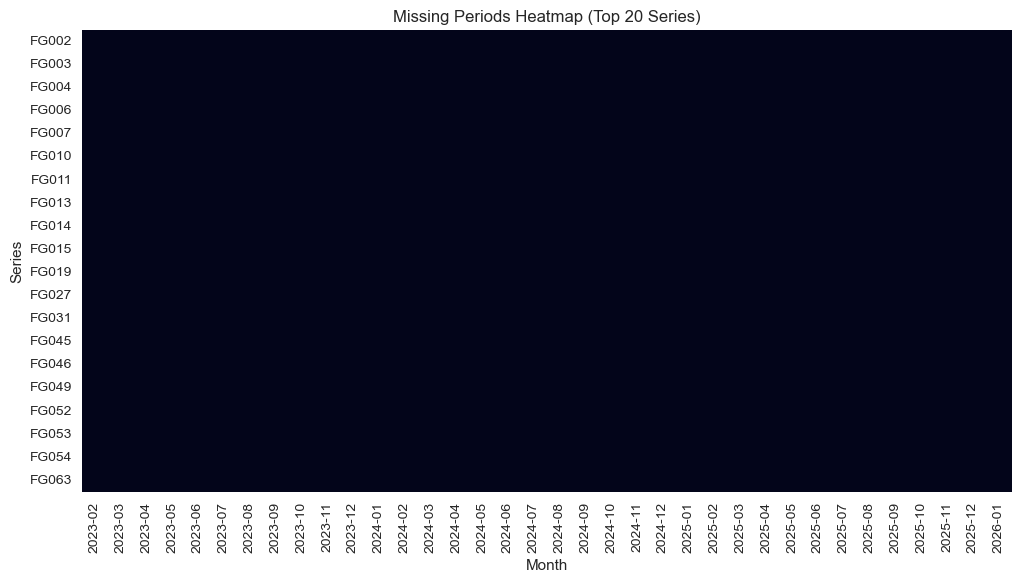

In [30]:
# 15) Missing Data Visualization
if TIME_COL in df.columns and SERIES_COL in df.columns:
    tmp = df.copy()
    tmp[TIME_COL] = pd.to_datetime(tmp[TIME_COL], errors="coerce")
    tmp = tmp.dropna(subset=[TIME_COL])
    tmp["period"] = tmp[TIME_COL].dt.to_period("M")

    # Heatmap of missing periods for top series
    top_series = (
        tmp.groupby(SERIES_COL)[TARGET_COL]
        .sum()
        .sort_values(ascending=False)
        .head(20)
        .index.tolist()
    )
    heat_df = tmp[tmp[SERIES_COL].isin(top_series)][[SERIES_COL, "period"]]
    if not heat_df.empty:
        pivot = (
            heat_df.assign(present=1)
            .pivot_table(index=SERIES_COL, columns="period", values="present", fill_value=0)
        )
        plt.figure(figsize=(12, 6))
        sns.heatmap(pivot, cbar=False)
        plt.title("Missing Periods Heatmap (Top 20 Series)")
        plt.xlabel("Month")
        plt.ylabel("Series")
        plt.show()
else:
    print("Missing TIME_COL or SERIES_COL; cannot plot missing data heatmap.")


In [31]:
# 16) Duplicate Check per (Time, Series)
if TIME_COL in df.columns and SERIES_COL in df.columns:
    dup_keys = df.duplicated(subset=[TIME_COL, SERIES_COL]).sum()
    print(f"Duplicate (time, series) rows: {dup_keys}")
    dup_table = (
        df.groupby([TIME_COL, SERIES_COL]).size().reset_index(name="count").query("count > 1")
    )
    print("Sample duplicate groups:")
    print(dup_table.head(10))
else:
    print("Missing TIME_COL or SERIES_COL; cannot compute duplicates by key.")


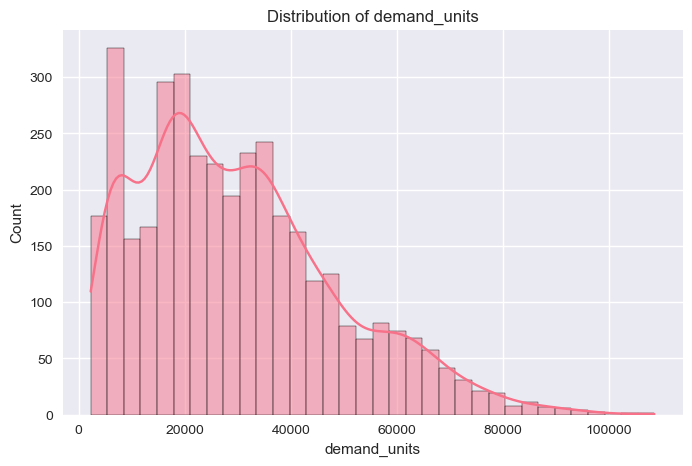

In [32]:
# 17) Distribution Plot (Histogram/KDE)
if TARGET_COL in df.columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[TARGET_COL].dropna(), kde=True)
    plt.title(f"Distribution of {TARGET_COL}")
    plt.xlabel(TARGET_COL)
    plt.ylabel("Count")
    plt.show()
else:
    print("Target column not found.")


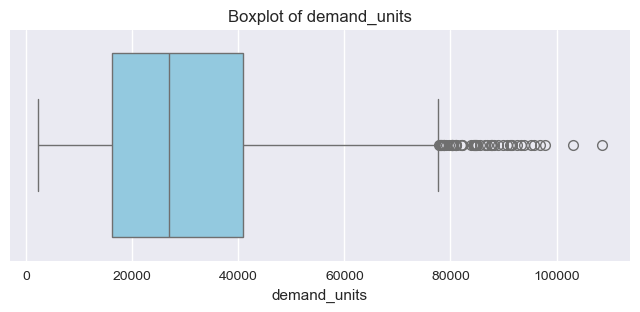

In [33]:
# 18) Box Plot (Outliers)
if TARGET_COL in df.columns:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df[TARGET_COL].dropna(), color="skyblue")
    plt.title(f"Boxplot of {TARGET_COL}")
    plt.xlabel(TARGET_COL)
    plt.show()
else:
    print("Target column not found.")


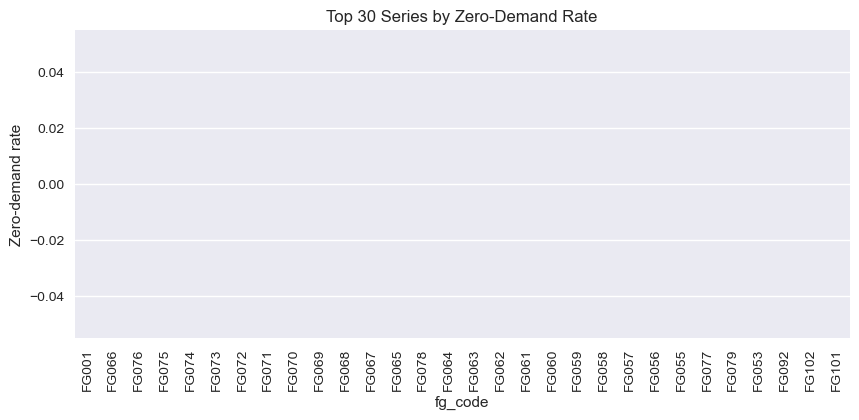

In [34]:
# 19) Zero Demand Analysis (Percent Zeros per Series)
if TARGET_COL in df.columns and SERIES_COL in df.columns:
    zero_rate = (
        df.groupby(SERIES_COL)[TARGET_COL]
        .apply(lambda s: float((s == 0).mean()))
        .sort_values(ascending=False)
        .reset_index(name="zero_rate")
    )
    print("Zero demand rate summary:")
    print(zero_rate["zero_rate"].describe())

    plt.figure(figsize=(10, 4))
    sns.barplot(data=zero_rate.head(30), x=SERIES_COL, y="zero_rate")
    plt.title("Top 30 Series by Zero-Demand Rate")
    plt.xticks(rotation=90)
    plt.ylabel("Zero-demand rate")
    plt.show()
else:
    print("Missing TARGET_COL or SERIES_COL; cannot compute zero-demand rate.")


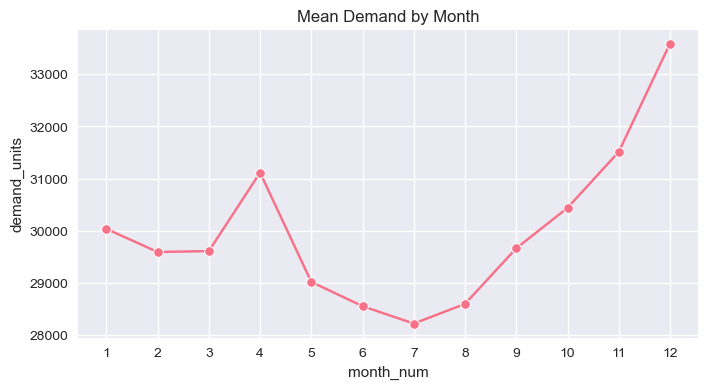

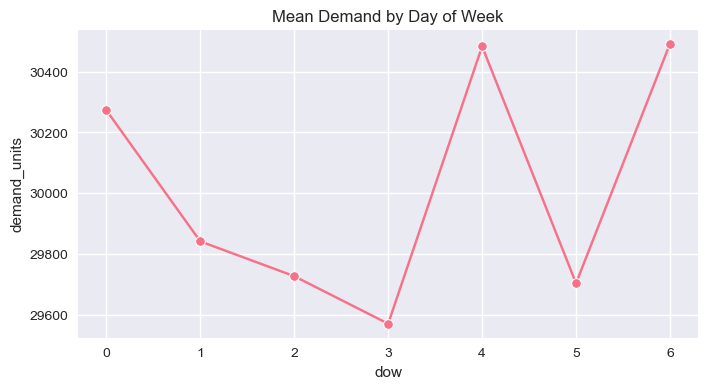

In [35]:
# 20) Seasonal Pattern Plots (Month and Day-of-Week if available)
if TIME_COL in df.columns and TARGET_COL in df.columns:
    tmp = df.dropna(subset=[TIME_COL]).copy()
    tmp[TIME_COL] = pd.to_datetime(tmp[TIME_COL], errors="coerce")

    tmp["month_num"] = tmp[TIME_COL].dt.month
    month_mean = tmp.groupby("month_num")[TARGET_COL].mean().reset_index()
    plt.figure(figsize=(8, 4))
    sns.lineplot(data=month_mean, x="month_num", y=TARGET_COL, marker="o")
    plt.title("Mean Demand by Month")
    plt.xticks(range(1, 13))
    plt.show()

    if tmp[TIME_COL].dt.freq is None:
        tmp["dow"] = tmp[TIME_COL].dt.dayofweek
        dow_mean = tmp.groupby("dow")[TARGET_COL].mean().reset_index()
        plt.figure(figsize=(8, 4))
        sns.lineplot(data=dow_mean, x="dow", y=TARGET_COL, marker="o")
        plt.title("Mean Demand by Day of Week")
        plt.xticks(range(0, 7))
        plt.show()
else:
    print("Missing TIME_COL or TARGET_COL; cannot plot seasonal patterns.")


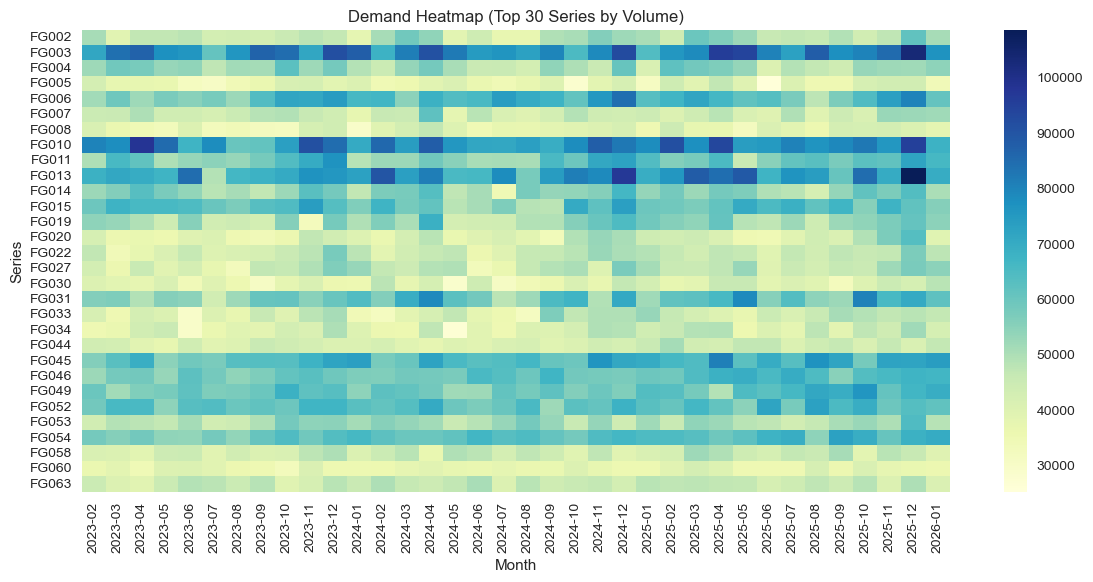

In [36]:
# 21) Heatmap: Series vs Month
if TIME_COL in df.columns and SERIES_COL in df.columns and TARGET_COL in df.columns:
    tmp = df.dropna(subset=[TIME_COL]).copy()
    tmp["period"] = pd.to_datetime(tmp[TIME_COL], errors="coerce").dt.to_period("M")

    top_series = (
        tmp.groupby(SERIES_COL)[TARGET_COL]
        .sum()
        .sort_values(ascending=False)
        .head(30)
        .index.tolist()
    )
    heat_df = tmp[tmp[SERIES_COL].isin(top_series)]
    pivot = (
        heat_df.pivot_table(index=SERIES_COL, columns="period", values=TARGET_COL, aggfunc="sum")
        .fillna(0)
    )

    plt.figure(figsize=(14, 6))
    sns.heatmap(pivot, cmap="YlGnBu")
    plt.title("Demand Heatmap (Top 30 Series by Volume)")
    plt.xlabel("Month")
    plt.ylabel("Series")
    plt.show()
else:
    print("Missing TIME_COL, SERIES_COL, or TARGET_COL; cannot plot heatmap.")


<Figure size 800x400 with 0 Axes>

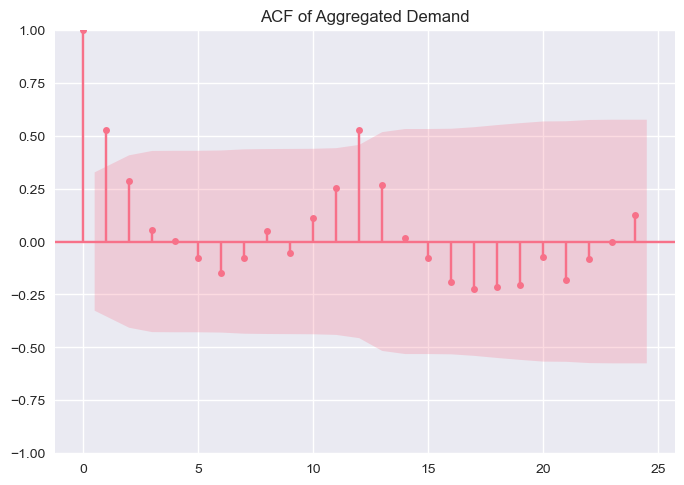

In [37]:
# 22) Autocorrelation (ACF)
try:
    from statsmodels.graphics.tsaplots import plot_acf
except Exception as exc:
    plot_acf = None
    print(f"statsmodels not available for ACF: {exc}")

if plot_acf and TIME_COL in df.columns and TARGET_COL in df.columns:
    ts = df.dropna(subset=[TIME_COL]).copy()
    ts[TIME_COL] = pd.to_datetime(ts[TIME_COL], errors="coerce")
    agg = ts.groupby(ts[TIME_COL].dt.to_period("M"))[TARGET_COL].sum()
    plt.figure(figsize=(8, 4))
    plot_acf(agg.dropna(), lags=24)
    plt.title("ACF of Aggregated Demand")
    plt.show()
else:
    print("Skipping ACF (missing deps or columns).")


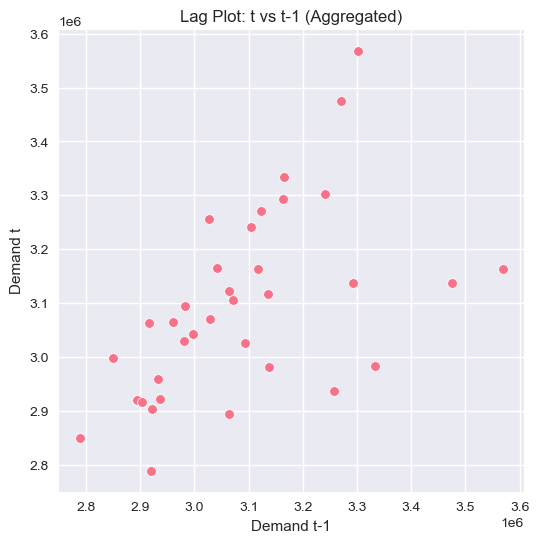

In [38]:
# 23) Lag Plot (t vs t-1)
if TIME_COL in df.columns and TARGET_COL in df.columns:
    ts = df.dropna(subset=[TIME_COL]).copy()
    ts[TIME_COL] = pd.to_datetime(ts[TIME_COL], errors="coerce")
    agg = ts.groupby(ts[TIME_COL].dt.to_period("M"))[TARGET_COL].sum().reset_index()
    agg["lag_1"] = agg[TARGET_COL].shift(1)
    plt.figure(figsize=(6, 6))
    sns.scatterplot(data=agg, x="lag_1", y=TARGET_COL)
    plt.title("Lag Plot: t vs t-1 (Aggregated)")
    plt.xlabel("Demand t-1")
    plt.ylabel("Demand t")
    plt.show()
else:
    print("Missing TIME_COL or TARGET_COL; cannot plot lag scatter.")


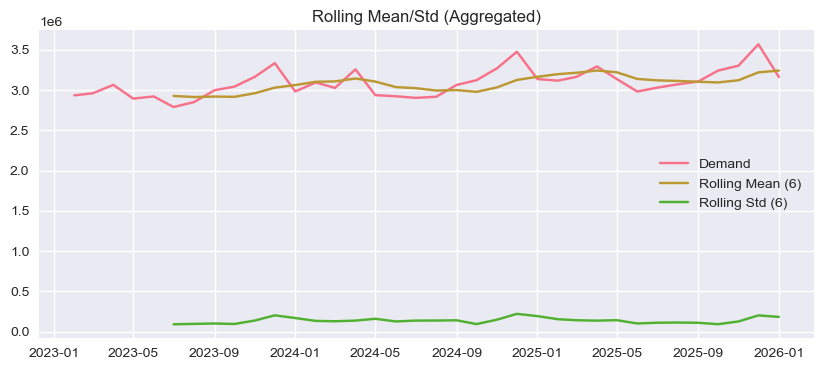

In [39]:
# 24) Rolling Statistics Plot
if TIME_COL in df.columns and TARGET_COL in df.columns:
    ts = df.dropna(subset=[TIME_COL]).copy()
    ts[TIME_COL] = pd.to_datetime(ts[TIME_COL], errors="coerce")
    agg = ts.groupby(ts[TIME_COL].dt.to_period("M"))[TARGET_COL].sum()
    roll_mean = agg.rolling(6).mean()
    roll_std = agg.rolling(6).std()

    plt.figure(figsize=(10, 4))
    plt.plot(agg.index.to_timestamp(), agg.values, label="Demand")
    plt.plot(roll_mean.index.to_timestamp(), roll_mean.values, label="Rolling Mean (6)")
    plt.plot(roll_std.index.to_timestamp(), roll_std.values, label="Rolling Std (6)")
    plt.title("Rolling Mean/Std (Aggregated)")
    plt.legend()
    plt.show()
else:
    print("Missing TIME_COL or TARGET_COL; cannot plot rolling stats.")


Decomposition failed: Failed to convert value(s) to axis units: (datetime.date(1970, 1, 1), datetime.date(1970, 1, 2))


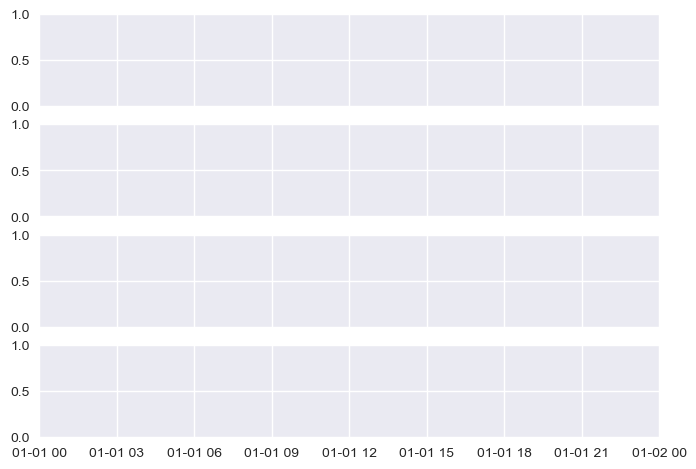

In [40]:
# 25) Trend Decomposition
try:
    from statsmodels.tsa.seasonal import seasonal_decompose
except Exception as exc:
    seasonal_decompose = None
    print(f"statsmodels not available for decomposition: {exc}")

if seasonal_decompose and TIME_COL in df.columns and TARGET_COL in df.columns:
    ts = df.dropna(subset=[TIME_COL]).copy()
    ts[TIME_COL] = pd.to_datetime(ts[TIME_COL], errors="coerce")
    agg = ts.groupby(ts[TIME_COL].dt.to_period("M"))[TARGET_COL].sum()
    try:
        result = seasonal_decompose(agg, model="additive", period=12)
        result.plot()
        plt.show()
    except Exception as exc:
        print(f"Decomposition failed: {exc}")
else:
    print("Skipping decomposition (missing deps or columns).")


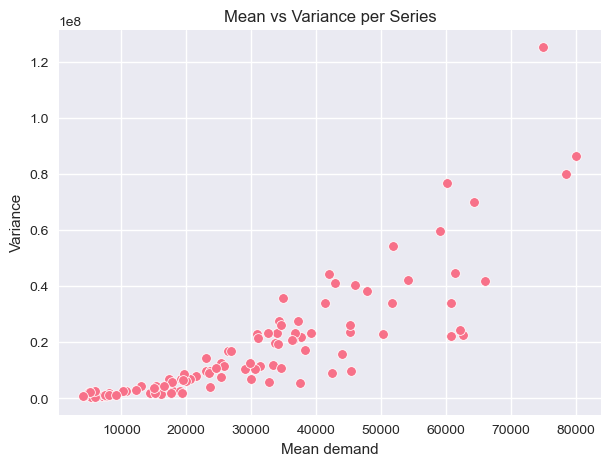

In [41]:
# 26) Demand Pattern Classification (Mean vs Variance)
if TARGET_COL in df.columns and SERIES_COL in df.columns:
    pattern = (
        df.groupby(SERIES_COL)[TARGET_COL]
        .agg(["mean", "var"])
        .reset_index()
    )
    plt.figure(figsize=(7, 5))
    sns.scatterplot(data=pattern, x="mean", y="var")
    plt.title("Mean vs Variance per Series")
    plt.xlabel("Mean demand")
    plt.ylabel("Variance")
    plt.show()
else:
    print("Missing TARGET_COL or SERIES_COL; cannot plot mean vs variance.")


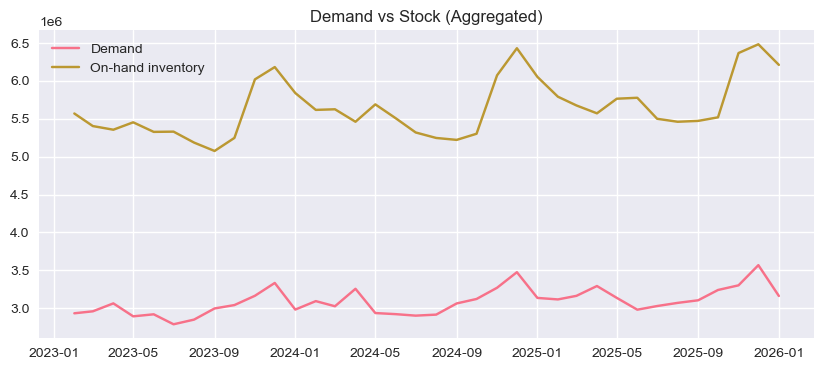

In [42]:
# 27) Stock vs Demand Plot (if stock column exists)
if TIME_COL in df.columns and TARGET_COL in df.columns and "on_hand_inventory" in df.columns:
    tmp = df.dropna(subset=[TIME_COL]).copy()
    tmp[TIME_COL] = pd.to_datetime(tmp[TIME_COL], errors="coerce")
    agg = tmp.groupby(tmp[TIME_COL].dt.to_period("M"))[[TARGET_COL, "on_hand_inventory"]].sum().reset_index()
    agg[TIME_COL] = agg[TIME_COL].dt.to_timestamp()

    plt.figure(figsize=(10, 4))
    plt.plot(agg[TIME_COL], agg[TARGET_COL], label="Demand")
    plt.plot(agg[TIME_COL], agg["on_hand_inventory"], label="On-hand inventory")
    plt.title("Demand vs Stock (Aggregated)")
    plt.legend()
    plt.show()
else:
    print("Stock column not available; skipping stock vs demand plot.")


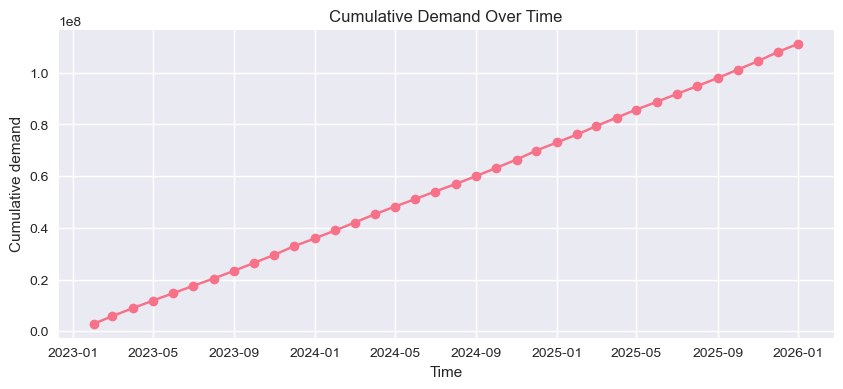

In [43]:
# 28) Cumulative Demand Curve
if TIME_COL in df.columns and TARGET_COL in df.columns:
    ts = df.dropna(subset=[TIME_COL]).copy()
    ts[TIME_COL] = pd.to_datetime(ts[TIME_COL], errors="coerce")
    agg = ts.groupby(ts[TIME_COL].dt.to_period("M"))[TARGET_COL].sum().reset_index()
    agg["cumulative"] = agg[TARGET_COL].cumsum()
    agg[TIME_COL] = agg[TIME_COL].dt.to_timestamp()

    plt.figure(figsize=(10, 4))
    plt.plot(agg[TIME_COL], agg["cumulative"], marker="o")
    plt.title("Cumulative Demand Over Time")
    plt.xlabel("Time")
    plt.ylabel("Cumulative demand")
    plt.show()
else:
    print("Missing TIME_COL or TARGET_COL; cannot plot cumulative demand.")
